In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

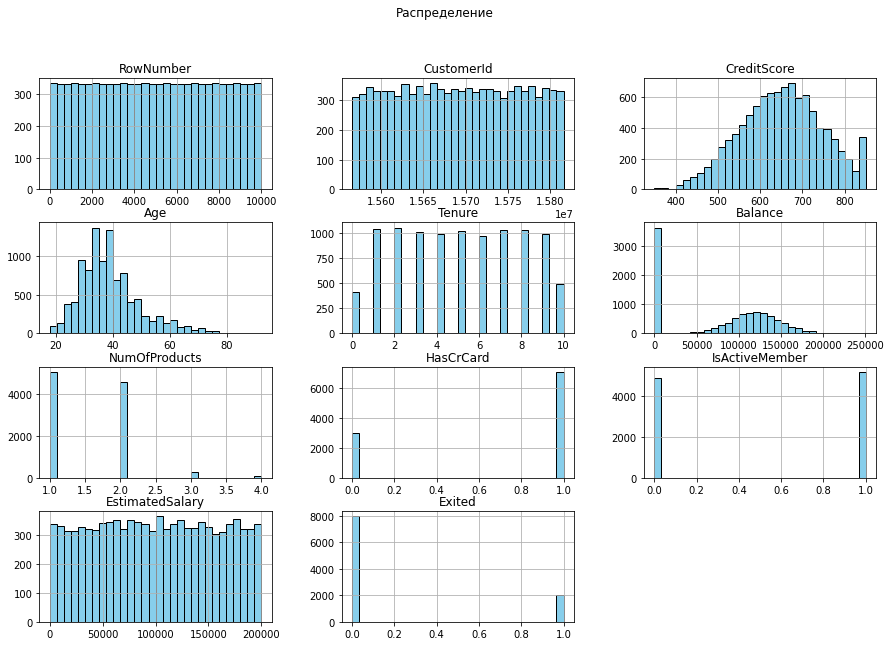

In [8]:
#Анализ числовых признаков
df.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')

plt.suptitle('Распределение')
plt.show()

In [12]:
#проверка на распределение
for col in df.columns:
    print(f"Признак: {col}")
    print(df[col].value_counts(normalize=True).map(lambda x: "{0:.2f}%".format(100 * x)))


Признак: RowNumber
1        0.01%
6671     0.01%
6664     0.01%
6665     0.01%
6666     0.01%
         ...  
3334     0.01%
3335     0.01%
3336     0.01%
3337     0.01%
10000    0.01%
Name: RowNumber, Length: 10000, dtype: object
Признак: CustomerId
15634602    0.01%
15667932    0.01%
15766185    0.01%
15667632    0.01%
15599024    0.01%
            ...  
15599078    0.01%
15702300    0.01%
15660735    0.01%
15671390    0.01%
15628319    0.01%
Name: CustomerId, Length: 10000, dtype: object
Признак: Surname
Smith       0.32%
Scott       0.29%
Martin      0.29%
Walker      0.28%
Brown       0.26%
            ...  
Izmailov    0.01%
Bold        0.01%
Bonham      0.01%
Poninski    0.01%
Burbidge    0.01%
Name: Surname, Length: 2932, dtype: object
Признак: CreditScore
850    2.33%
678    0.63%
655    0.54%
705    0.53%
667    0.53%
       ...  
404    0.01%
351    0.01%
365    0.01%
417    0.01%
419    0.01%
Name: CreditScore, Length: 460, dtype: object
Признак: Geography
France     50.14%


In [14]:
from scipy.stats import zscore
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
z_scores = np.abs(zscore(df[numerical_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("\nКол-во выбросов по каждому числовому признаку (|z|>3):\n", dict(zip(numerical_cols, outliers)))


Кол-во выбросов по каждому числовому признаку (|z|>3):
 {'RowNumber': 0, 'CustomerId': 0, 'CreditScore': 8, 'Age': 133, 'Tenure': 0, 'Balance': 0, 'NumOfProducts': 60, 'HasCrCard': 0, 'IsActiveMember': 0, 'EstimatedSalary': 0, 'Exited': 0}


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, features):
    X = df[features].dropna()
    vif = pd.DataFrame()
    vif['Feature'] = features
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

vif_df = calculate_vif(df, numerical_cols)
print("\nVIF (Проверка мультиколлинеарности):\n", vif_df)


VIF (Проверка мультиколлинеарности):
             Feature        VIF
0         RowNumber   4.002844
1        CustomerId  83.184609
2       CreditScore  46.347812
3               Age  16.405859
4            Tenure   4.011030
5           Balance   2.793324
6     NumOfProducts   8.742618
7         HasCrCard   3.398460
8    IsActiveMember   2.158265
9   EstimatedSalary   4.034073
10           Exited   1.438506
